# Pokemon TCG Card Data — Exploratory Analysis

Strategy track: Pokemon TCG AI Battle Challenge

Goal: understand the card pool (types, HP, moves, costs) to inform deck
archetype design and agent decision logic for the strategy report.

In [1]:
import sys
sys.path.append('..')

import pandas as pd
import matplotlib.pyplot as plt

from src.data_loader import load_card_data, categorize_cards

pd.set_option('display.max_columns', None)

In [2]:
df = load_card_data('EN')
print(df.shape)
df.head()

(2022, 17)


,Card ID,Card Name,Expansion,Collection No.,Stage (Pokémon)/Type (Energy and Trainer),Rule,Category,Previous stage,HP,Type,Weakness,Resistance (Type),Retreat,Move Name,Cost,Damage,Effect Explanation
0,1,Basic {G} Energy,SVE,1,Basic Energy,NaN,NaN,NaN,NaN,{G},NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,Basic {R} Energy,SVE,2,Basic Energy,NaN,NaN,NaN,NaN,{R},NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,Basic {W} Energy,SVE,3,Basic Energy,NaN,NaN,NaN,NaN,{W},NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,Basic {L} Energy,SVE,4,Basic Energy,NaN,NaN,NaN,NaN,{L},NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,Basic {P} Energy,SVE,5,Basic Energy,NaN,NaN,NaN,NaN,{P},NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Split into Pokemon / Trainer / Energy

In [3]:
groups = categorize_cards(df)
pokemon_df = groups['pokemon']
trainer_df = groups['trainer']
energy_df = groups['energy']

for name, g in groups.items():
    print(name, len(g))

pokemon 1815
trainer 187
energy 20


## Pokemon type distribution

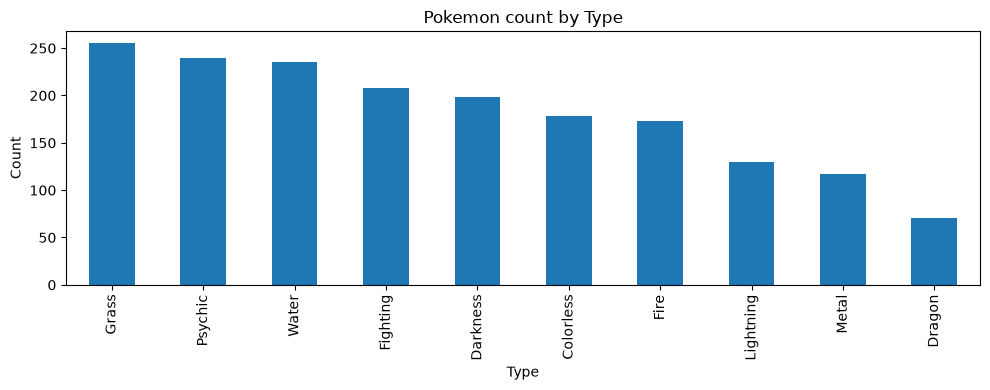

In [4]:
from src.data_loader import readable_type

type_counts = pokemon_df['Type'].apply(readable_type).value_counts()
type_counts.plot(kind='bar', figsize=(10, 4), title='Pokemon count by Type')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

## HP distribution

In [5]:
pokemon_df['HP'].describe()

count    1815.000000
mean      131.289256
std        73.287066
min        30.000000
25%        80.000000
50%       110.000000
75%       150.000000
max       380.000000
Name: HP, dtype: float64

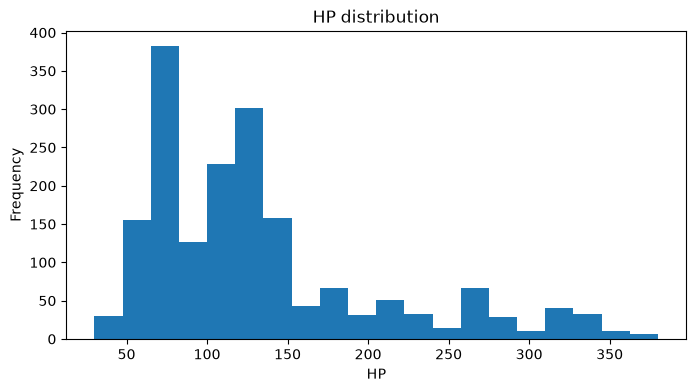

In [6]:
pokemon_df['HP'].plot(kind='hist', bins=20, figsize=(8, 4), title='HP distribution')
plt.xlabel('HP')
plt.show()

## Evolution stages (Basic / Stage 1 / Stage 2)

In [7]:
stage_col = 'Stage (Pokémon)/Type (Energy and Trainer)'
pokemon_df[stage_col].value_counts()

Stage (Pokémon)/Type (Energy and Trainer)
Basic Pokémon      958
Stage 1 Pokémon    618
Stage 2 Pokémon    229
Item                10
Name: count, dtype: int64

## Trainer card categories

In [8]:
trainer_df['Category'].value_counts()

Category
Ancient              2
Future               2
Technical Machine    2
Name: count, dtype: int64

## Weakness / Resistance patterns (relevant for matchup strategy)

In [9]:
print('Weakness counts:')
print(pokemon_df['Weakness'].value_counts())
print()
print('Resistance counts:')
print(pokemon_df['Resistance (Type)'].value_counts())

Weakness counts:
Weakness
{R}    361
{F}    323
{L}    258
{G}    247
{W}    166
{D}    157
{M}    156
{P}     66
Name: count, dtype: int64

Resistance counts:
Resistance (Type)
{F}    266
{G}    110
Name: count, dtype: int64


## Retreat cost distribution

In [10]:
pokemon_df['Retreat'].value_counts().sort_index()

Retreat
1.0    859
2.0    554
3.0    265
4.0     70
Name: count, dtype: int64

## Attack efficiency: damage per energy spent

Cost strings use curly-brace tokens for specific energy types (e.g. `{G}`)
and filled circles (`●`) for Colorless energy. Damage strings sometimes
carry modifiers (`×` for coin-flip multipliers, `+` for conditional bonus
damage) which we strip to get a comparable base value.

In [11]:
from src.data_loader import add_move_metrics

moves = add_move_metrics(pokemon_df)
moves['Type'] = moves['Type'].apply(readable_type)
moves_with_dmg = moves.dropna(subset=['damage_per_energy'])

print(f'{len(moves_with_dmg)} attacking moves with a direct damage value')
moves_with_dmg[['Card Name', 'Type', 'Move Name', 'energy_cost', 'base_damage', 'damage_per_energy']]\
    .sort_values('damage_per_energy', ascending=False).head(15)

1281 attacking moves with a direct damage value


,Card Name,Type,Move Name,energy_cost,base_damage,damage_per_energy
184,Palafin ex,Water,Giga Impact,1,250.0,250.0
1216,Tinkaton,Metal,Windup Swing,1,240.0,240.0
1372,Ceruledge,Fire,Infernal Slash,1,220.0,220.0
229,Decidueye,Grass,Power Shot,1,170.0,170.0
57,Greninja ex,Fighting,Shinobi Blade,1,170.0,170.0
1513,Medicham,Fighting,Seventh Kick,1,150.0,150.0
1819,Diggersby,Colorless,Earthquake,1,140.0,140.0
428,Slaking ex,Colorless,Great Swing,2,280.0,140.0
1184,Mega Lucario ex,Fighting,Mega Brave,2,270.0,135.0
77,Palafin,Water,Vanguard Punch,1,130.0,130.0


In [12]:
moves_with_dmg.groupby('energy_cost')['base_damage'].agg(['mean', 'median', 'count'])

,mean,median,count
energy_cost,,,
1,30.239651,20.0,459
2,57.132701,50.0,422
3,113.413174,100.0,334
4,162.166667,150.0,60
5,226.666667,235.0,6


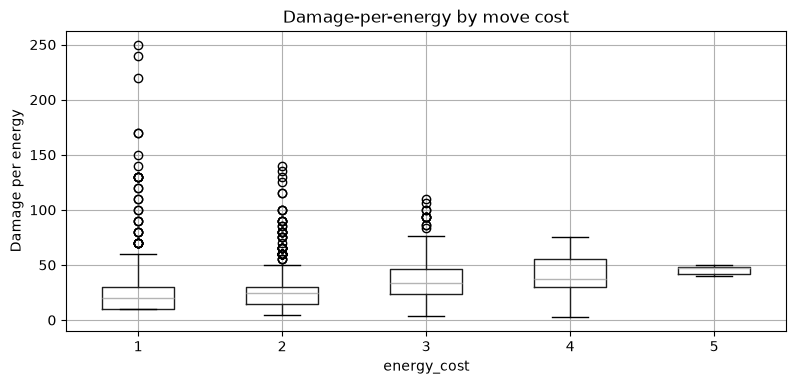

In [13]:
moves_with_dmg.boxplot(column='damage_per_energy', by='energy_cost', figsize=(9, 4))
plt.title('Damage-per-energy by move cost')
plt.suptitle('')
plt.ylabel('Damage per energy')
plt.show()

## Energy type coverage

How often each energy type is required across all attacking moves —
informs which energy types an agent needs to prioritize acquiring/attaching.

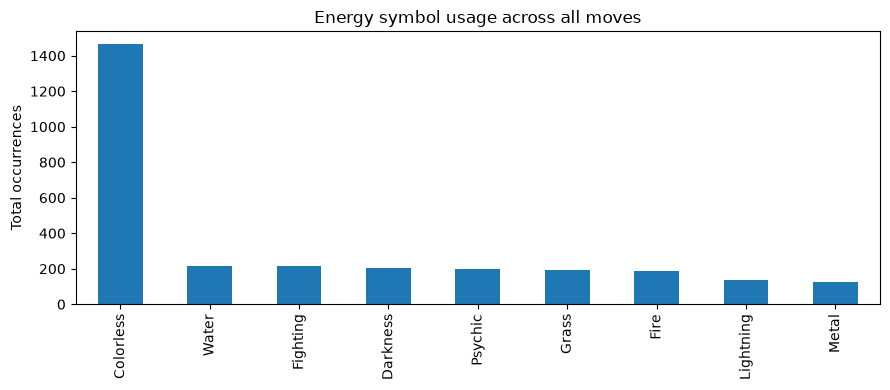

Colorless    1464
Water         218
Fighting      214
Darkness      207
Psychic       197
Grass         193
Fire          187
Lightning     137
Metal         123
dtype: int64

In [14]:
from src.data_loader import parse_cost
from collections import Counter

energy_counter = Counter()
for cost in pokemon_df['Cost'].dropna():
    for energy_type, count in parse_cost(cost).items():
        energy_counter[energy_type] += count

energy_series = pd.Series(energy_counter).sort_values(ascending=False)
energy_series.plot(kind='bar', figsize=(9, 4), title='Energy symbol usage across all moves')
plt.ylabel('Total occurrences')
plt.tight_layout()
plt.show()
energy_series

## Candidate deck archetypes by type

For each Pokemon type, look at: how many attackers exist, their average
HP and damage-per-energy, and average retreat cost. Types with strong
efficiency + low retreat cost + reasonable HP are good archetype anchors.

In [15]:
moves_by_type = moves_with_dmg.groupby('Type').agg(
    attackers=('Card Name', 'nunique'),
    avg_hp=('HP', 'mean'),
    avg_damage_per_energy=('damage_per_energy', 'mean'),
    avg_retreat=('Retreat', 'mean'),
).sort_values('avg_damage_per_energy', ascending=False)

moves_by_type.round(2)

,attackers,avg_hp,avg_damage_per_energy,avg_retreat
Type,,,,
Dragon,31,148.30,41.737589,1.73
Fighting,101,128.79,35.493631,2.12
Metal,57,139.56,34.65,2.03
Lightning,60,138.72,34.193262,1.33
Fire,83,137.05,33.905685,1.92
Water,125,128.09,31.273408,1.88
Colorless,94,122.52,30.823848,1.56
Grass,122,114.75,30.235405,1.57
Darkness,90,130.85,30.088028,1.78


## Type matchup matrix (weakness exploitation)

Rows = attacker type (deals 2x damage to...), columns = defender type.
Cell value = count of unique defender-type Pokemon that are weak to the
attacker type. This tells us which types have the broadest "predator"
coverage across the metagame, and which types are safest from weakness
exploitation entirely.

In [ ]:
from src.data_loader import build_matchup_matrix

matchup = build_matchup_matrix(pokemon_df)
matchup

In [ ]:
print('Total unique Pokemon weak to each attacking type:')
print(matchup.sum(axis=1).sort_values(ascending=False))
print()
print('Total unique Pokemon of each type that ARE weak to something (i.e. exploitable):')
print(matchup.sum(axis=0).sort_values())

**Key finding:** Dragon-type Pokemon have *no* Weakness value in this
dataset at all (35/35 are NaN) — this matches real Pokemon TCG rules,
where Dragon has no assigned weakness type. Combined with Dragon's #1
damage-per-energy ranking, this makes Dragon a strong anchor type: it
can't be weakness-punished by any deck, though its small pool (35 unique
cards) may limit consistency. Fire is the single best "predator" type
(220 unique Pokemon across the pool are weak to Fire), making a Fire
attacker line a safe secondary pick with broad matchup coverage.

## Trainer support: draw/search vs disruption

Trainer cards accelerate consistency (draw/search) or disrupt the
opponent. Skimming category + effect text helps decide which support
package pairs best with a given attacker archetype.

In [16]:
pd.set_option('display.max_colwidth', 100)
trainer_df[['Card Name', 'Category', 'Effect Explanation']].head(20)

,Card Name,Category,Effect Explanation
1825,Roto-Stick,NaN,Look at the top 4 cards of your deck. You may reveal any number of Supporter cards you find ther...
1826,Hole-Digging Shovel,NaN,Discard the top 2 cards of your deck.
1827,Rare Candy,NaN,Choose 1 of your Basic Pokémon in play. If you have a Stage 2 card in your hand that evolves fro...
1828,Unfair Stamp,NaN,You can use this card only if any of your Pokémon were Knocked Out during your opponent’s last t...
1829,Enhanced Hammer,NaN,Discard a Special Energy from 1 of your opponent’s Pokémon.
1830,Hyper Aroma,NaN,"Search your deck for up to 3 Stage 1 Pokémon, reveal them, and put them into your hand. Then, sh..."
1831,Love Ball,NaN,"Search your deck for a Pokémon with the same name as 1 of your opponent’s Pokémon in play, revea..."
1832,Boxed Order,NaN,"Search your deck for up to 2 Item cards, reveal them, and put them into your hand. Then, shuffle..."
1833,Awakening Drum,Ancient,Draw a card for each of your Ancient Pokémon in play.
1834,Buddy-Buddy Poffin,NaN,Search your deck for up to 2 Basic Pokémon with 70 HP or less and put them onto your Bench. Then...


## Takeaways for the strategy report

- Single-energy-cost attackers with 100+ damage (e.g. Palafin ex, Tinkaton,
  Ceruledge) offer the best damage-per-energy ratio and support fast,
  aggressive agent decision logic (attach one energy, attack immediately).
- Energy symbol usage is dominated by Colorless (●, 1,464 occurrences vs.
  ~120-220 per specific type), meaning most attackers don't lock the agent
  into a single energy type — this favors flexible, multi-type decks over
  hard-committed mono-type strategies.
- By type-level average damage-per-energy: **Dragon (41.7)**, Fighting
  (35.5), and Metal (34.7) lead the pack, while Grass (30.2) and Psychic
  (28.1) trail. Dragon also has strong average HP (148) — a good anchor
  type for a primary attacker archetype, though the Dragon-type pool is
  smaller (31 attackers vs. 90-125 for the mid-tier types), so consistency
  may be harder to guarantee.
- Retreat cost matters for agent stability: Lightning (1.33 avg) and
  Colorless (1.56) attackers retreat cheaply, reducing the risk of being
  stuck against an unfavorable matchup, whereas Fighting (2.12) and Metal
  (2.03) attackers commit more heavily once in the active spot.
- Next: cross-reference Weakness/Resistance with the chosen archetype's
  types to model matchup risk, then draft 2-3 concrete deck lists with
  Pokemon + Trainer + Energy counts (60-card deck) for the report.